In [164]:
# --- modules ---
import pandas as pd 
import glob, os, sys, re
from pathlib import Path
import rootutils
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# --- hard coded paths ---
ROOT_PATH = rootutils.find_root(search_from=Path.cwd(), indicator=".git")
sys.path.append(str(ROOT_PATH))
ROOTDIR_DATA = os.path.join(ROOT_PATH, "Data", "processed")
sys.path.append(ROOTDIR_DATA)

# --- hard coded constants ---
from Scripts.constants import (
    CATCHMENT_AREA_DEMER, #area in km2
)

# code to load the data

In [165]:
# --- load the excel sheet with data ---
data=os.path.join(ROOTDIR_DATA, "Data_practical2.xlsx")

#read in the different events for 2020 and 2023
df_2020=pd.read_excel(data, sheet_name=0, header=0, usecols=[0, 1, 2])
df_2023=pd.read_excel(data, sheet_name=1, header=0, usecols=[0, 1, 2])

# --- convert the precipitation to m3/h and the discharge to m3/h ---
for df in [df_2020, df_2023]:
    df["P (m3/h)"]=df["P (mm/h)"]*CATCHMENT_AREA_DEMER*1000
    df["Q (m3/h)"]=df["Q (m3/s)"]*3600

# Question 1: make hydrographs for both 2020 and 2023

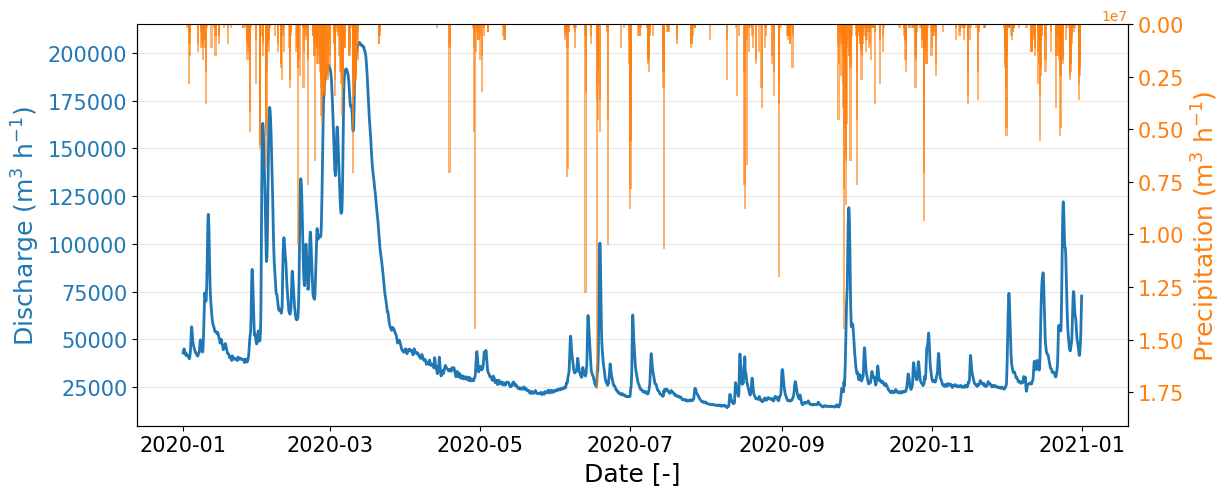

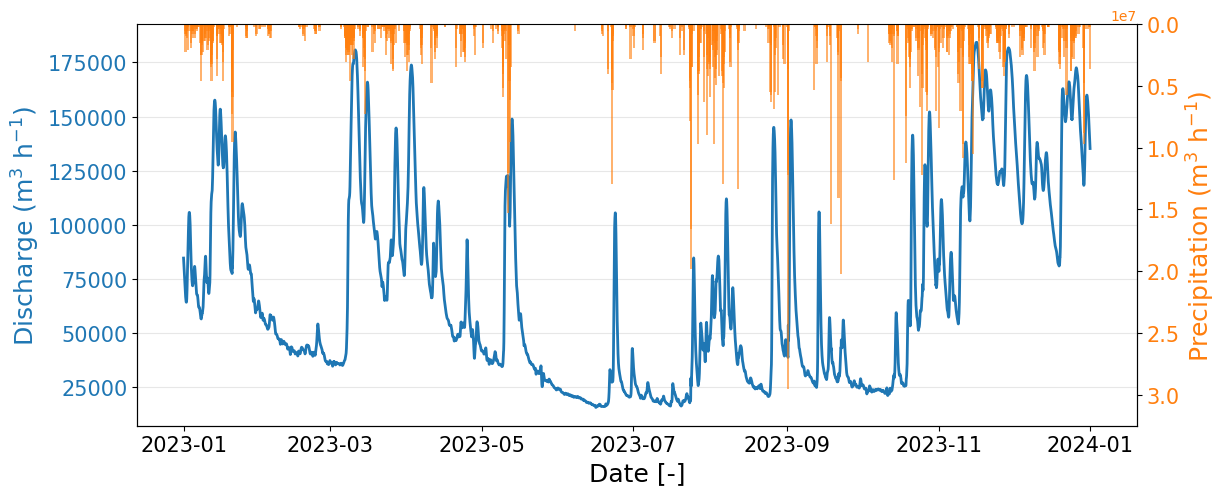

In [153]:
def PlotHydrographYear(
        df: pd.DataFrame
    ) -> plt.figure:
    """
    Function to plot the hydrograph of a given event.
    """
    #---make the plot---
    fig, ax = plt.subplots(figsize=(12, 5))

    #discharge at the bottom
    ax.plot(
        df["Datum_tijd"],
        df["Q (m3/h)"],
        color="tab:blue",
        lw=2,
    )
    ax.set_ylabel("Discharge (m$^3$ h$^{-1}$)", color="tab:blue", fontsize=18)
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax.spines["top"].set_visible(False)

    #precipitation  at the top
    ax2 = ax.twinx()
    ax2.bar(
        df["Datum_tijd"],
        df["P (m3/h)"],
        width=0.9,
        color="tab:orange",
        alpha=0.6,
    )
    ax2.invert_yaxis()
    ax2.set_ylim(df["P (m3/h)"].max() * 1.1, 0) #0 at the top

    # Move ticks and label to the top
    ax2.xaxis.set_visible(False)
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()

    ax2.set_ylabel("Precipitation (m$^3$ h$^{-1}$)", color="tab:orange", fontsize=18)
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    # Cosmetics
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("Date [-]", fontsize=18)
    fig.tight_layout()

    ax.tick_params(axis="both", labelsize=15)
    ax2.tick_params(axis="y", labelsize=15)

    plt.show()

PlotHydrographYear(df_2020)
PlotHydrographYear(df_2023)

# Question 2: Make a figure of discharge and P for a specific event

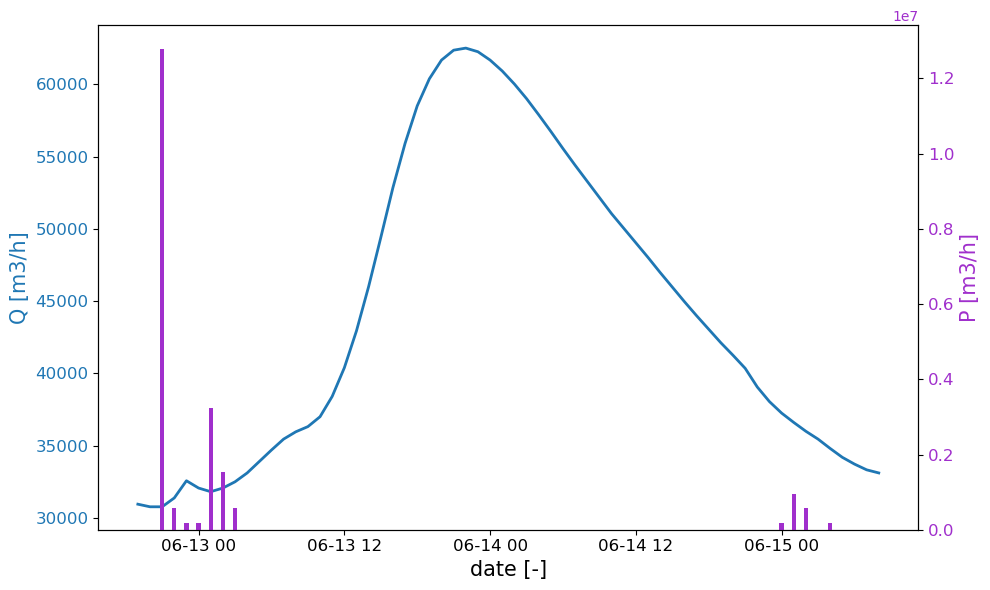

The maximum discharge appears after 25 hours
The baseflow is 30780.0 m3/h
The total direct runoff for this event is 826740.0 m3/h


In [154]:
def PlotHydrographEvent2020(
    date_ini:pd.Timestamp = pd.to_datetime("2020-06-12 18:00:00.000"),
    date_end:pd.Timestamp = pd.to_datetime("2020-06-15 08:00:00.000"),
    df:pd.DataFrame = df_2020.copy()
    ) -> tuple[plt.figure, pd.DataFrame]:
    """
    Function to plot the hydrograph of a given event. 
    Note that also the output for the different questions is printed in the console.
    """

    # --- take the subset ---
    df_sub = df.loc[(df_2020["Datum_tijd"] >= date_ini) & 
                (df_2020["Datum_tijd"] <= date_end)].copy()

    # --- plot the hydrograph ---
    fig,ax=plt.subplots(figsize=(10,6))
    ax.plot(df_sub["Datum_tijd"], df_sub["Q (m3/h)"], color="tab:blue", lw=2)
    ax.set_xlabel("date [-]", fontsize=15)
    ax.set_ylabel("Q [m3/h]", color="tab:blue", fontsize=15)
    ax.tick_params(axis="y", labelcolor="tab:blue")


    ax2=ax.twinx()
    ax2.bar(df_sub["Datum_tijd"], df_sub["P (m3/h)"], color="#A02FCC", width=0.015)
    ax2.set_ylabel("P [m3/h]",color="#A02FCC", fontsize=15)
    ax2.tick_params(axis="y", labelcolor="#A02FCC")

    for ax in [ax, ax2]:
        ax.tick_params(axis="both", labelsize=12)
    fig.tight_layout()
    plt.show()

    #calculate after how many hours the discharge is maximal
    Tstart_P = df_sub.loc[df_sub["P (m3/h)"] != 0,
                        "Datum_tijd"].iloc[0]

    Tmax_Q = df_sub.loc[df_sub["Q (m3/h)"]==np.max(df_sub["Q (m3/h)"]), 
                        "Datum_tijd"].iloc[0]

    print(f"The maximum discharge appears after {round((Tmax_Q-Tstart_P).total_seconds()/3600)} hours")

    #now compute the base flow
    Q_base = np.floor(df_sub["Q (m3/h)"].min())
    print(f"The baseflow is {Q_base} m3/h")

    #calculate the direct runoff
    df_sub["Q_direct (m3/h)"] = df_sub["Q (m3/h)"]-Q_base
    print(f"The total direct runoff for this event is {df_sub['Q_direct (m3/h)'].sum()} m3/h")

    return fig, df_sub

_, df_sub = PlotHydrographEvent2020()

# Question 3 $\phi$-method

In [173]:
# calculate the discharge in mm of the direct discharge
df_sub["Q_direct (mm/h)"] = df_sub["Q_direct (m3/h)"]/(CATCHMENT_AREA_DEMER*1000)

#calculate the effective precipitation -> equation 6.18
print(f"The netto effective precipitation is {df_sub['Q_direct (mm/h)'].sum()}")

#calculate the phi index

#get the rainevent leading to the hydrograph -> this is the first event of the subset (VISUAL INSPECTION)
P_rainevent = df_sub.loc[\
    (df_sub["Datum_tijd"] <= pd.to_datetime("2020-06-14")) & 
    (df_sub["P (mm/h)"] > 0)
    ].copy()

#calculate phi 
duration_rainevent = (P_rainevent["Datum_tijd"].max() - P_rainevent["Datum_tijd"].min()).total_seconds()/3600
phi = -(df_sub["Q_direct (mm/h)"].sum() - P_rainevent["P (mm/h)"].sum()) / duration_rainevent
print(f"The value for phi is {phi} mm/h")

#calculate the adjustment for the phi-index
adj = 1
P_rainevent["Peff"] = np.where(P_rainevent["P (mm/h)"]-(phi+adj) < 0,
                               0,
                               P_rainevent["P (mm/h)"]-(phi+adj))

diff=np.abs(df_sub["Q_direct (mm/h)"].sum()-P_rainevent["Peff"].sum())
while diff > 0.01:

    adj=adj+0.001 #add increment to the adjustment

    P_rainevent["Peff"] = np.where(P_rainevent["P (mm/h)"]-(phi+adj) < 0,
                                   0,
                                    P_rainevent["P (mm/h)"]-(phi+adj)
                                    )
    
    diff = np.abs(df_sub["Q_direct (mm/h)"].sum() - P_rainevent["Peff"].sum())

print(f"The phi-index needs to be adjusted with: {round(adj,2)}")
print(f"The final phi is {phi+adj} mm/h")

phi=phi+adj

The netto effective precipitation is 0.4334542169913722
The value for phi is 1.5944242971681046 mm/h
The phi-index needs to be adjusted with: 4.66
The final phi is 6.257424297167995 mm/h


# Question 4: Plot the discharge and getthe unit hydrograph

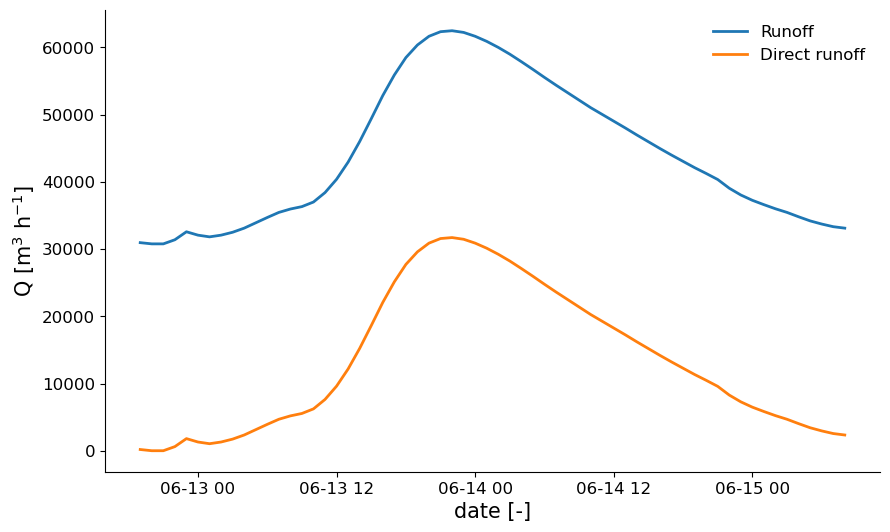

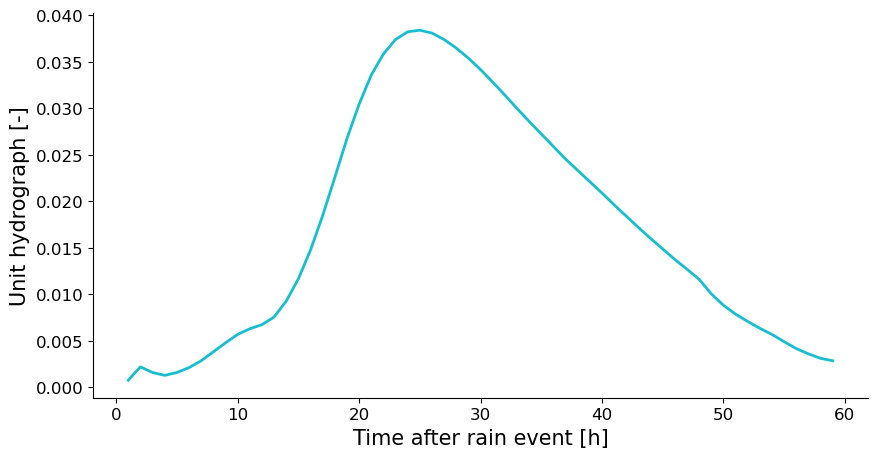

In [174]:
# --- plot the total and direct runoff ---
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(df_sub["Datum_tijd"], df_sub["Q (m3/h)"], color="tab:blue", label="Runoff", lw=2)
ax.plot(df_sub["Datum_tijd"], df_sub["Q_direct (m3/h)"], color="tab:orange", label="Direct runoff", lw=2)
ax.legend(loc="best", frameon=False, fontsize=12)

ax.set_xlabel("date [-]", fontsize=15)
ax.set_ylabel("Q [m$^3$ h$^{-1}$]", fontsize=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=12)

# --- plot the UH ---
# get the unit hydrograph
begin_hydrograph = df_sub.loc[df_sub["P (mm/h)"] > 0].index[0]
df_hydrograh = df_sub.loc[begin_hydrograph+1:,].reset_index(drop=True).copy()
df_hydrograh["UH"] = df_hydrograh["Q_direct (m3/h)"] / df_hydrograh["Q_direct (m3/h)"].sum()
df_hydrograh["time_after_rain"] = np.linspace(1, df_hydrograh.shape[0], df_hydrograh.shape[0])

# plot the UH
fig,ax = plt.subplots(figsize=(10,5))
ax.plot(df_hydrograh["time_after_rain"], df_hydrograh["UH"], color="tab:cyan", lw=2)
ax.set_ylabel("Unit hydrograph [-]", fontsize=15)
ax.set_xlabel("Time after rain event [h]", fontsize=15)
ax.tick_params(axis="both", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Question 5: compute the estimated dscharge for a rain event in 2023

The bias is -795.5808107511973
The RMSE is 6635.492244516534
The correlation is 0.7720528402196659


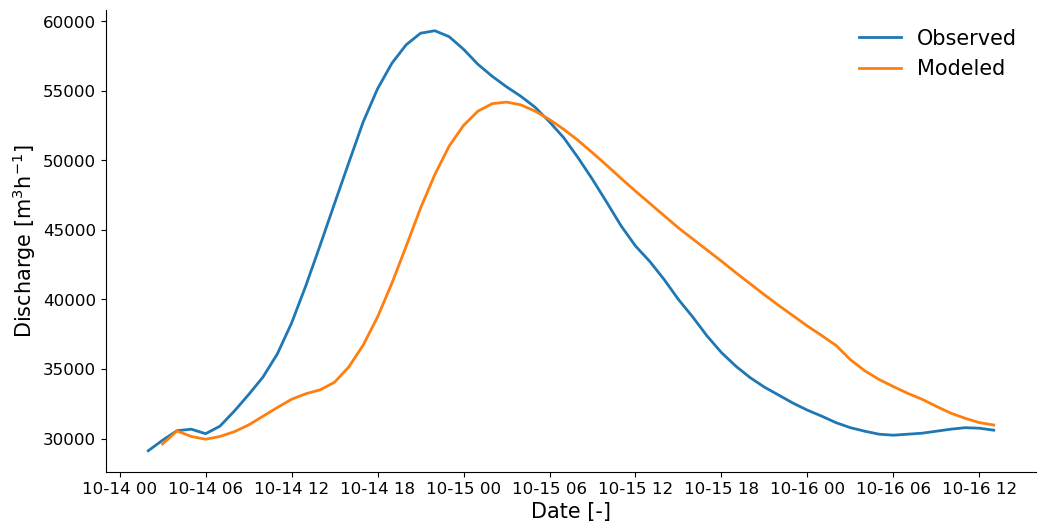

In [ ]:
date_ini = pd.to_datetime("2023-10-14 01:00:00.00")
date_end = pd.to_datetime("2023-10-16 13:00:00.00")

# --- calculate the discharge ---
df_q5=df_2023.loc[
                (df_2023["Datum_tijd"] >= date_ini) & 
                (df_2023["Datum_tijd"] <= date_end)
                ].copy()

# calculate the effective precipitation for the hydrograph
rainevent = df_q5.loc[
                    (df_q5["Datum_tijd"] <= pd.to_datetime("2023-10-15")) & 
                    (df_q5["P (m3/h)"] > 0)
                    ].copy()

phi_m3h=phi*CATCHMENT_AREA_DEMER*1000

rainevent["Peff"] = np.where(rainevent["P (m3/h)"]-phi_m3h <0, 0, \
                                rainevent["P (m3/h)"]-phi_m3h )
Peff = rainevent["Peff"].sum()

#calculate the base flow
Qbase_q5 = df_q5["Q (m3/h)"].min()

#calculate the modelled discharge
UH = df_hydrograh["UH"] * Peff + Qbase_q5

#add to dataframe
df_q5["Q_modeled"] = np.nan
df_q5.loc[rainevent.index[0]+1:, "Q_modeled"] = UH.values

#plot
fig, ax=plt.subplots(figsize=(12,6))
ax.plot(df_q5["Datum_tijd"], df_q5["Q (m3/h)"],color="tab:blue", label="Observed", lw=2)
ax.plot(df_q5["Datum_tijd"], df_q5["Q_modeled"], color="tab:orange", label="Modeled", lw=2)
ax.set_xlabel("Date [-]", fontsize=15)
ax.set_ylabel("Discharge [m$^3$h$^{-1}$]", fontsize=15)
ax.legend(fontsize=15, frameon=False, loc="upper right")
ax.tick_params(axis="both", labelsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#calculate the bias and RMSE
df_q5=df_q5.dropna()

print(f"The bias is {np.mean(df_q5['Q_modeled']-df_q5['Q (m3/h)'])}")
print(f"The RMSE is {root_mean_squared_error(df_q5['Q_modeled'],df_q5['Q (m3/h)'])}")
print(f"The correlation is {np.corrcoef(df_q5['Q_modeled'], df_q5['Q (m3/h)'])[1,0]}")